In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
gavin = pd.read_csv("data/final_S_Gavin Walsh.csv", on_bad_lines='skip')
gavin.attrs['filepath'] = "data/final_S_Gavin Walsh.csv"

trenton = pd.read_csv("data/final_S_Trenton Yu.csv", on_bad_lines='skip')
trenton.attrs['filepath'] = "data/final_S_Trenton Yu.csv"

ryan = pd.read_csv("data/final_S_ryan.csv", on_bad_lines='skip')
ryan.attrs['filepath'] = "data/final_S_ryan.csv"

In [11]:
gavin.columns

Index(['success', 'trial_type', 'trial_index', 'time_elapsed',
       'internal_node_id', 'rt', 'responses', 'subject_id', 'stimulus',
       'key_press', 'prompt', 'response', 'choice_outcomes', 'context_n',
       'context_img_id', 'trial_n', 'pR_red', 'pR_white', 'pR_black',
       'outcome', 'phase', 'passed', 'island_num', 'context_im',
       'contextArray_ind', 'pRew_Red', 'pRew_White', 'pRew_Black'],
      dtype='str')

In [47]:
def count_coins(df):
    filepath = df.attrs.get('filepath')
    if filepath is None:
        raise ValueError("DataFrame must have 'filepath' set in df.attrs")
    
    total = 0
    with open(filepath, 'r') as f:
        for line in f:
            if 'do_trial' not in line:
                continue
            fields = line.strip().split(',')
            if len(fields) < 23:
                continue
            phase = fields[22]
            outcome = fields[21]
            if phase in ('learn', 'judgement') and outcome in ('0', '1'):
                total += int(outcome)
    return total

In [51]:
count_coins(gavin)

122

In [37]:
with open("data/final_S_Gavin Walsh.csv", 'r') as f:
    lines = f.readlines()

# find do_bye lines
for i, line in enumerate(lines):
    if 'do_bye' in line:
        print(f"=== Line {i} ===")
        print(line)
        print(f"=== Line {i-1} (before) ===")
        print(lines[i-1])
        print(f"=== Line {i+1} (after) ===")
        print(lines[i+1])

=== Line 53 ===
,do_bye,52,175505,0.0-38.0-0.0,null,,,,,,null,,,,,,,,,,,,,,,,

=== Line 52 (before) ===
,do_trial,51,173996,0.0-37.0-1.0,758.5,,,,,,51,1,0,0,,,,,,,,,,,,,,,

=== Line 54 (after) ===
,do_travel,53,184511,0.0-38.0-1.0,null,,,,,,null,,,,,,,,,,,,,,,,

=== Line 158 ===
,do_bye,157,412237,0.0-86.0-1.0,null,,,,,,null,,,,,,,,,,,,,,,,

=== Line 157 (before) ===
,attention_check,156,410730,0.0-86.0-0.0,2857.3000000000466,,,<div style='position:relative; margin-top: 600px;'><p>Before we set sail — press the <b>Z</b> key to continue!</p></div>,90,,,,,,,,,,,,true,,,,,,

=== Line 159 (after) ===
,break,158,429451,0.0-86.0-2.0,17212.300000000047,,,<div class='center'><p>Time to take a quick break! You have 2 minutes to rest, but you can move on sooner if you'd like.</p><p> Press the <b>space bar</b> to continue.</p></div>,32,,,,,,,,,,,,,,,,,,

=== Line 243 ===
,do_bye,242,606156,0.0-128.0-1.0,null,,,,,,null,,,,,,,,,,,,,,,,

=== Line 242 (before) ===
,attention_check,241,604648,0.0-128.

In [52]:
import pandas as pd
import glob
import os

def most_chosen_pirate_per_island(trials_df):
    learn = trials_df[trials_df['phase'] == 'learn']
    return (
        learn.groupby('context_im')['chosen_pirate']
        .agg(lambda x: x.value_counts().idxmax())
        .reset_index()
        .rename(columns={'chosen_pirate': 'most_chosen'})
    )

# Load all trials files
all_results = []
for filepath in glob.glob("data/cleaned/final_S_*_trials.csv"):
    df = pd.read_csv(filepath)
    subject = df['subject_id'].iloc[0]
    result = most_chosen_pirate_per_island(df)
    result['subject_id'] = subject
    all_results.append(result)

summary = pd.concat(all_results).pivot(index='subject_id', columns='context_im', values='most_chosen')
print(summary)

context_im    city  coast countryside forest highway mountain
subject_id                                                   
Gavin Walsh  white  white         red    red   white      red
Trenton Yu   white    red       white    red   black    white
ryan           red    red       black  black     red    white


In [54]:
def ground_truth_best_per_island(trials_df):
    learn = trials_df[trials_df['phase'] == 'learn']
    avg_probs = learn.groupby('context_im')[['pR_red', 'pR_white', 'pR_black']].mean()
    best = avg_probs.idxmax(axis=1).str.replace('pR_', '')
    return best.reset_index().rename(columns={0: 'ground_truth'})

all_chosen = []
all_gt = []

for filepath in glob.glob("data/cleaned/final_S_*_trials.csv"):
    df = pd.read_csv(filepath)
    subject = df['subject_id'].iloc[0]
    
    chosen = most_chosen_pirate_per_island(df)
    chosen['subject_id'] = subject
    all_chosen.append(chosen)
    
    gt = ground_truth_best_per_island(df)
    gt['subject_id'] = subject
    all_gt.append(gt)

chosen_df = pd.concat(all_chosen)
gt_df = pd.concat(all_gt)

merged = chosen_df.merge(gt_df, on=['subject_id', 'context_im'])
merged['correct'] = merged['most_chosen'] == merged['ground_truth']

print(merged.to_string(index=False))

 context_im most_chosen  subject_id ground_truth  correct
       city       white Gavin Walsh          red    False
      coast       white Gavin Walsh        white     True
countryside         red Gavin Walsh          red     True
     forest         red Gavin Walsh          red     True
    highway       white Gavin Walsh        white     True
   mountain         red Gavin Walsh          red     True
       city       white  Trenton Yu        white     True
      coast         red  Trenton Yu          red     True
countryside       white  Trenton Yu          red    False
     forest         red  Trenton Yu        white    False
    highway       black  Trenton Yu        black     True
   mountain       white  Trenton Yu        white     True
       city         red        ryan          red     True
      coast         red        ryan        white    False
countryside       black        ryan        black     True
     forest       black        ryan          red    False
    highway   

In [58]:
def judgement_regression_matrix(trials_df):
    """
    For each judgement trial, creates a 1/0 matrix indicating whether
    the participant chose the most-sampled pirate from the learning phase.
    Returns a (60, 3) matrix where columns = [red, white, black].
    """
    learn = trials_df[trials_df['phase'] == 'learn']
    judgement = trials_df[trials_df['phase'] == 'judgement'].reset_index(drop=True)

    # Shape verification
    subject = trials_df['subject_id'].iloc[0]
    assert len(judgement) == 60, f"{subject}: expected 60 judgement trials, got {len(judgement)}"

    # Find most sampled pirate per island during learning
    most_sampled = (
        learn.groupby('context_im')['chosen_pirate']
        .agg(lambda x: x.value_counts().idxmax())
        .to_dict()
    )

    pirates = ['red', 'white', 'black']
    matrix = pd.DataFrame(0, index=judgement.index, columns=pirates)

    for idx, row in judgement.iterrows():
        island = row['context_im']
        top_pirate = most_sampled.get(island)
        if top_pirate:
            matrix.loc[idx, top_pirate] = 1

    assert matrix.shape == (60, 3), f"{subject}: unexpected matrix shape {matrix.shape}"
    assert matrix.sum(axis=1).eq(1).all(), f"{subject}: some rows don't sum to 1"

    return matrix

In [90]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Load cleaned trials for the three participants
participants = {
    'Gavin Walsh': pd.read_csv("data/cleaned/final_S_Gavin Walsh_trials.csv"),
    'Trenton Yu':  pd.read_csv("data/cleaned/final_S_Trenton Yu_trials.csv"),
    'Ryan':        pd.read_csv("data/cleaned/final_S_ryan_trials.csv"),
}

# Single clean test: is the log-odds of choosing most-sampled 
# pirate different from chance (log(1/3 / 2/3) = -log(2) ≈ -0.693)?
# Use one intercept-only model and offset by log(1/2) to test against 1/3

def run_regression(trials_df):
    subject = trials_df['subject_id'].iloc[0]
    learn = trials_df[trials_df['phase'] == 'learn']
    judgement = trials_df[trials_df['phase'] == 'judgement'].dropna(subset=['chosen_pirate']).reset_index(drop=True)

    most_sampled = (
        learn.groupby('context_im')['chosen_pirate']
        .agg(lambda x: x.value_counts().idxmax())
        .to_dict()
    )

    y = (judgement['chosen_pirate'] == judgement['context_im'].map(most_sampled)).astype(int).values
    n = len(y)

    # Intercept-only model
    X = np.ones((n, 1))

    # Offset: log-odds of chance (1/3) to test against 1/3 rather than 1/2
    chance_log_odds = np.log(1/3 / (2/3))  # = -0.693
    offset = np.full(n, chance_log_odds)

    model = sm.Logit(y, X)
    result = model.fit(disp=0, offset=offset)

    # coef > 0 means above chance (1/3), coef < 0 means below chance
    coef = result.params[0]
    pval = result.pvalues[0]
    ci_lo, ci_hi = result.conf_int()[0]

    return {
        'subject_id':              subject,
        'coef':                    coef,        # log-odds relative to 1/3 chance
        'ci_lo':                   ci_lo,
        'ci_hi':                   ci_hi,
        'pval':                    pval,
        'prop_chose_most_sampled': y.mean(),
        'n_trials':                n,
    }

results = []
for name, df in participants.items():
    try:
        res = run_regression(df)
        results.append(res)
        print(f"✓ {name}")
    except Exception as e:
        print(f"✗ {name}: {e}")

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

✓ Gavin Walsh
✓ Trenton Yu
✓ Ryan
 subject_id      coef     ci_lo     ci_hi     pval  prop_chose_most_sampled  n_trials
Gavin Walsh  0.307485 -0.208890  0.823859 0.243171                 0.576271        59
 Trenton Yu -0.988611 -1.562569 -0.414654 0.000736                 0.271186        59
       ryan -1.652923 -2.366058 -0.939788 0.000006                 0.160714        56


/Users/aidangoeschel/Documents/UCI/CCNL/CounterfactualBandit/.venv/lib/python3.13/site-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: offset. After release 0.14, this will raise.
  warnings.warn(
/Users/aidangoeschel/Documents/UCI/CCNL/CounterfactualBandit/.venv/lib/python3.13/site-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: offset. After release 0.14, this will raise.
  warnings.warn(
/Users/aidangoeschel/Documents/UCI/CCNL/CounterfactualBandit/.venv/lib/python3.13/site-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments hav

In [88]:
RT_THRESHOLD = 150  # ms

def run_regression(trials_df):
    subject = trials_df['subject_id'].iloc[0]
    learn = trials_df[trials_df['phase'] == 'learn']
    judgement = (trials_df[trials_df['phase'] == 'judgement']
                 .dropna(subset=['chosen_pirate', 'rt'])
                 .query('rt >= @RT_THRESHOLD')
                 .reset_index(drop=True))

    print(f"{subject}: {len(judgement)} valid judgement trials after RT filter")

    most_sampled = (
        learn[learn['rt'] >= RT_THRESHOLD]  # also exclude fast learn trials from most_sampled
        .groupby('context_im')['chosen_pirate']
        .agg(lambda x: x.value_counts().idxmax())
        .to_dict()
    )

    y = (judgement['chosen_pirate'] == judgement['context_im'].map(most_sampled)).astype(int).values
    n = len(y)

    X = np.ones((n, 1))
    chance_log_odds = np.log(1/3 / (2/3))
    offset = np.full(n, chance_log_odds)

    model = sm.Logit(y, X)
    result = model.fit(disp=0, offset=offset)

    coef = result.params[0]
    pval = result.pvalues[0]
    ci_lo, ci_hi = result.conf_int()[0]

    return {
        'subject_id':              subject,
        'coef':                    coef,
        'ci_lo':                   ci_lo,
        'ci_hi':                   ci_hi,
        'pval':                    pval,
        'prop_chose_most_sampled': y.mean(),
        'n_valid_trials':          n,
    }

results = []
for name, df in participants.items():
    try:
        res = run_regression(df)
        results.append(res)
    except Exception as e:
        print(f"✗ {name}: {e}")

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Gavin Walsh: 58 valid judgement trials after RT filter
Trenton Yu: 59 valid judgement trials after RT filter
ryan: 43 valid judgement trials after RT filter
 subject_id      coef     ci_lo     ci_hi     pval  prop_chose_most_sampled  n_valid_trials
Gavin Walsh  0.348307 -0.174230  0.870844 0.191399                 0.586207              58
 Trenton Yu -0.988611 -1.562569 -0.414654 0.000736                 0.271186              59
       ryan -1.475907 -2.243981 -0.707832 0.000166                 0.186047              43


/Users/aidangoeschel/Documents/UCI/CCNL/CounterfactualBandit/.venv/lib/python3.13/site-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: offset. After release 0.14, this will raise.
  warnings.warn(
/Users/aidangoeschel/Documents/UCI/CCNL/CounterfactualBandit/.venv/lib/python3.13/site-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method newton is: tol, ridge_factor. The list of unsupported keyword arguments passed include: offset. After release 0.14, this will raise.
  warnings.warn(
/Users/aidangoeschel/Documents/UCI/CCNL/CounterfactualBandit/.venv/lib/python3.13/site-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments hav

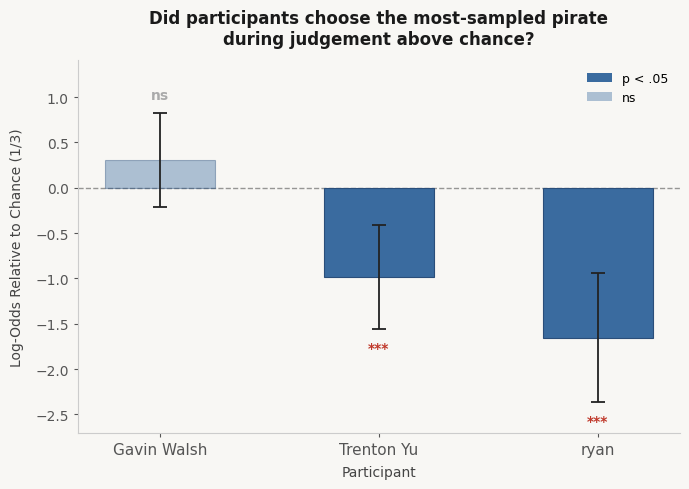

In [91]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#F8F7F4')
ax.set_facecolor('#F8F7F4')

subjects = results_df['subject_id'].tolist()
x_pos = np.arange(len(subjects))
bar_width = 0.5

for xi, subject in enumerate(subjects):
    row = results_df[results_df['subject_id'] == subject].iloc[0]
    coef  = row['coef']
    ci_lo = row['ci_lo']
    ci_hi = row['ci_hi']
    pval  = row['pval']
    alpha = 1.0 if pval < 0.05 else 0.4

    ax.bar(xi, coef, width=bar_width, color='#3A6B9F', edgecolor='#2A4E7A',
           linewidth=0.8, alpha=alpha, zorder=3)
    ax.errorbar(xi, coef, yerr=[[coef - ci_lo], [ci_hi - coef]],
                fmt='none', color='#222222', capsize=5, capthick=1.3,
                linewidth=1.3, zorder=4)

    if pval < 0.001:   sig = '***'
    elif pval < 0.01:  sig = '**'
    elif pval < 0.05:  sig = '*'
    else:              sig = 'ns'

    label_color = '#C0392B' if pval < 0.05 else '#AAAAAA'
    pad = (results_df['ci_hi'].max() - results_df['ci_lo'].min()) * 0.04
    if ci_hi >= 0:
        ax.text(xi, ci_hi + pad, sig, ha='center', va='bottom',
                fontsize=10, fontweight='bold', color=label_color, zorder=5)
    else:
        ax.text(xi, ci_lo - pad, sig, ha='center', va='top',
                fontsize=10, fontweight='bold', color=label_color, zorder=5)

ax.axhline(0, color='#555555', linewidth=1.0, linestyle='--', alpha=0.6, zorder=2)
ax.set_xticks(x_pos)
ax.set_xticklabels(subjects, fontsize=11)
ax.set_ylabel('Log-Odds Relative to Chance (1/3)', fontsize=10, color='#444444', labelpad=8)
ax.set_xlabel('Participant', fontsize=10, color='#444444', labelpad=6)
ax.set_title('Did participants choose the most-sampled pirate\nduring judgement above chance?',
             fontsize=12, fontweight='bold', color='#1A1A1A', pad=12)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#CCCCCC')
    ax.spines[spine].set_linewidth(0.8)
ax.tick_params(colors='#555555', length=3)

legend_elements = [
    mpatches.Patch(facecolor='#3A6B9F', alpha=1.0, label='p < .05'),
    mpatches.Patch(facecolor='#3A6B9F', alpha=0.4,  label='ns'),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=9, loc='upper right')

# Extend ylim to fit labels
ymin, ymax = ax.get_ylim()
data_range = ymax - ymin
ax.set_ylim(ymin - data_range * 0.05, ymax + data_range * 0.12)

plt.tight_layout()
plt.savefig('data/cleaned/regression_coefficients.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

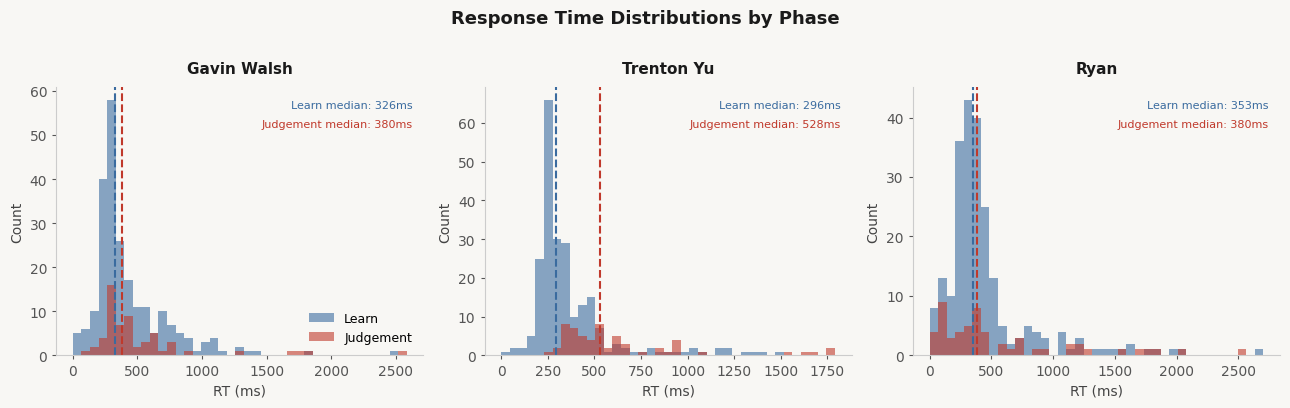

In [71]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
fig.patch.set_facecolor('#F8F7F4')

for ax, (subject, df) in zip(axes, participants.items()):
    ax.set_facecolor('#F8F7F4')
    
    learn     = df[df['phase'] == 'learn']['rt'].dropna()
    judgement = df[df['phase'] == 'judgement']['rt'].dropna()

    bins = np.linspace(0, max(learn.max(), judgement.max()), 40)

    ax.hist(learn,     bins=bins, alpha=0.6, color='#3A6B9F', label='Learn',     edgecolor='none')
    ax.hist(judgement, bins=bins, alpha=0.6, color='#C0392B', label='Judgement', edgecolor='none')

    ax.axvline(learn.median(),     color='#3A6B9F', linewidth=1.5, linestyle='--')
    ax.axvline(judgement.median(), color='#C0392B', linewidth=1.5, linestyle='--')

    ax.set_title(subject, fontsize=11, fontweight='bold', color='#1A1A1A', pad=10)
    ax.set_xlabel('RT (ms)', fontsize=10, color='#444444')
    ax.set_ylabel('Count', fontsize=10, color='#444444')

    ax.text(0.97, 0.95, f'Learn median: {learn.median():.0f}ms',
            transform=ax.transAxes, ha='right', va='top', fontsize=8, color='#3A6B9F')
    ax.text(0.97, 0.88, f'Judgement median: {judgement.median():.0f}ms',
            transform=ax.transAxes, ha='right', va='top', fontsize=8, color='#C0392B')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('#CCCCCC')
        ax.spines[spine].set_linewidth(0.8)
    ax.tick_params(colors='#555555', length=3)

axes[0].legend(frameon=False, fontsize=9)
fig.suptitle('Response Time Distributions by Phase', fontsize=13,
             fontweight='bold', color='#1A1A1A', y=1.01)

plt.tight_layout()
plt.savefig('data/cleaned/rt_distributions.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

Gavin Walsh: learn=0, judgement=1
Trenton Yu: learn=0, judgement=1
Ryan: learn=1, judgement=4


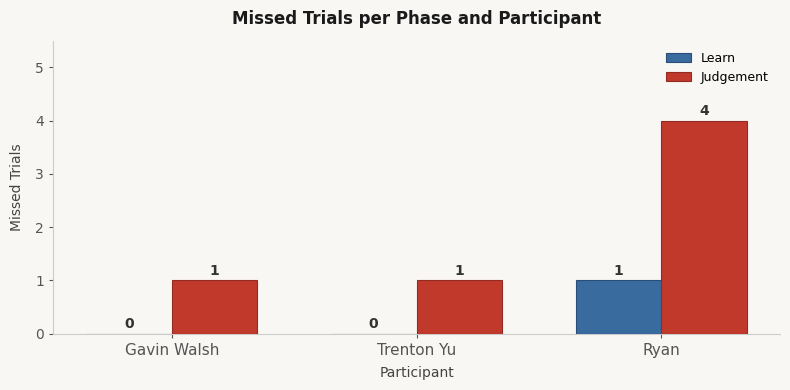

In [73]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#F8F7F4')
ax.set_facecolor('#F8F7F4')

subjects = list(participants.keys())
missed_learn, missed_judgement = [], []

for subject, df in participants.items():
    learn     = df[df['phase'] == 'learn']
    judgement = df[df['phase'] == 'judgement']
    missed_learn.append(learn['chosen_pirate'].isna().sum())
    missed_judgement.append(judgement['chosen_pirate'].isna().sum())
    print(f"{subject}: learn={missed_learn[-1]}, judgement={missed_judgement[-1]}")

x_pos = np.arange(len(subjects))
width = 0.35

bars_l = ax.bar(x_pos - width/2, missed_learn,     width=width, color='#3A6B9F',
                edgecolor='#2A4E7A', linewidth=0.8, label='Learn',     zorder=3)
bars_j = ax.bar(x_pos + width/2, missed_judgement, width=width, color='#C0392B',
                edgecolor='#922B21', linewidth=0.8, label='Judgement', zorder=3)

for xi, (nl, nj) in enumerate(zip(missed_learn, missed_judgement)):
    ax.text(xi - width/2, nl + 0.05, str(nl), ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#333333')
    ax.text(xi + width/2, nj + 0.05, str(nj), ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#333333')

ax.set_xticks(x_pos)
ax.set_xticklabels(subjects, fontsize=11)
ax.set_ylabel('Missed Trials', fontsize=10, color='#444444', labelpad=8)
ax.set_xlabel('Participant', fontsize=10, color='#444444', labelpad=6)
ax.set_title('Missed Trials per Phase and Participant',
             fontsize=12, fontweight='bold', color='#1A1A1A', pad=12)
ax.set_ylim(0, max(missed_learn + missed_judgement) + 1.5)
ax.legend(frameon=False, fontsize=9)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#CCCCCC')
    ax.spines[spine].set_linewidth(0.8)
ax.tick_params(colors='#555555', length=3)

plt.tight_layout()
plt.savefig('data/cleaned/missed_trials.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [74]:
for subject, df in participants.items():
    learn = df[df['phase'] == 'learn']
    print(f"\n=== {subject} ===")
    print(f"Total learn trials: {len(learn)}")
    print(f"NaN chosen_pirate: {learn['chosen_pirate'].isna().sum()}")
    print(f"NaN rt: {learn['rt'].isna().sum()}")
    print(f"chosen_pirate value counts (incl NaN):\n{learn['chosen_pirate'].value_counts(dropna=False)}")
    print(f"\nRows with NaN rt:")
    print(learn[learn['rt'].isna()][['trial_index','context_im','chosen_pirate','outcome','rt']].to_string())


=== Gavin Walsh ===
Total learn trials: 230
NaN chosen_pirate: 0
NaN rt: 0
chosen_pirate value counts (incl NaN):
chosen_pirate
red      90
white    79
black    61
Name: count, dtype: int64

Rows with NaN rt:
Empty DataFrame
Columns: [trial_index, context_im, chosen_pirate, outcome, rt]
Index: []

=== Trenton Yu ===
Total learn trials: 230
NaN chosen_pirate: 0
NaN rt: 0
chosen_pirate value counts (incl NaN):
chosen_pirate
white    111
red       64
black     55
Name: count, dtype: int64

Rows with NaN rt:
Empty DataFrame
Columns: [trial_index, context_im, chosen_pirate, outcome, rt]
Index: []

=== Ryan ===
Total learn trials: 230
NaN chosen_pirate: 1
NaN rt: 1
chosen_pirate value counts (incl NaN):
chosen_pirate
red      102
white     69
black     58
NaN        1
Name: count, dtype: int64

Rows with NaN rt:
     trial_index context_im chosen_pirate  outcome  rt
119          335   mountain           NaN      NaN NaN


Gavin Walsh: learn=11, judgement=2
Trenton Yu: learn=7, judgement=1
Ryan: learn=26, judgement=17


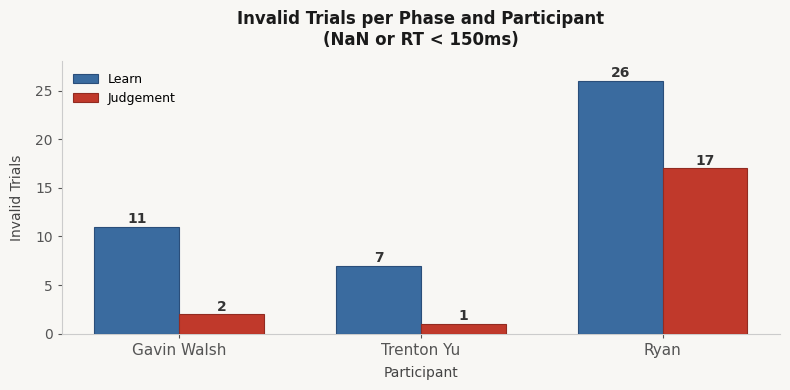

In [76]:
RT_THRESHOLD = 150  # ms

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#F8F7F4')
ax.set_facecolor('#F8F7F4')

subjects = list(participants.keys())
missed_learn, missed_judgement = [], []

for subject, df in participants.items():
    learn     = df[df['phase'] == 'learn']
    judgement = df[df['phase'] == 'judgement']

    # Missed = NaN rt OR rt below threshold
    n_missed_learn     = (learn['rt'].isna()     | (learn['rt']     < RT_THRESHOLD)).sum()
    n_missed_judgement = (judgement['rt'].isna()  | (judgement['rt'] < RT_THRESHOLD)).sum()

    missed_learn.append(n_missed_learn)
    missed_judgement.append(n_missed_judgement)
    print(f"{subject}: learn={n_missed_learn}, judgement={n_missed_judgement}")

x_pos = np.arange(len(subjects))
width = 0.35

ax.bar(x_pos - width/2, missed_learn,     width=width, color='#3A6B9F',
       edgecolor='#2A4E7A', linewidth=0.8, label='Learn',     zorder=3)
ax.bar(x_pos + width/2, missed_judgement, width=width, color='#C0392B',
       edgecolor='#922B21', linewidth=0.8, label='Judgement', zorder=3)

for xi, (nl, nj) in enumerate(zip(missed_learn, missed_judgement)):
    ax.text(xi - width/2, nl + 0.05, str(nl), ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#333333')
    ax.text(xi + width/2, nj + 0.05, str(nj), ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#333333')

ax.set_xticks(x_pos)
ax.set_xticklabels(subjects, fontsize=11)
ax.set_ylabel('Invalid Trials', fontsize=10, color='#444444', labelpad=8)
ax.set_xlabel('Participant', fontsize=10, color='#444444', labelpad=6)
ax.set_title(f'Invalid Trials per Phase and Participant\n(NaN or RT < {RT_THRESHOLD}ms)',
             fontsize=12, fontweight='bold', color='#1A1A1A', pad=12)
ax.set_ylim(0, max(missed_learn + missed_judgement) + 2)
ax.legend(frameon=False, fontsize=9)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#CCCCCC')
    ax.spines[spine].set_linewidth(0.8)
ax.tick_params(colors='#555555', length=3)

plt.tight_layout()
plt.savefig('data/cleaned/invalid_trials.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

Gavin Walsh: 47.9% optimal choices
Trenton Yu: 54.3% optimal choices
Ryan: 41.7% optimal choices


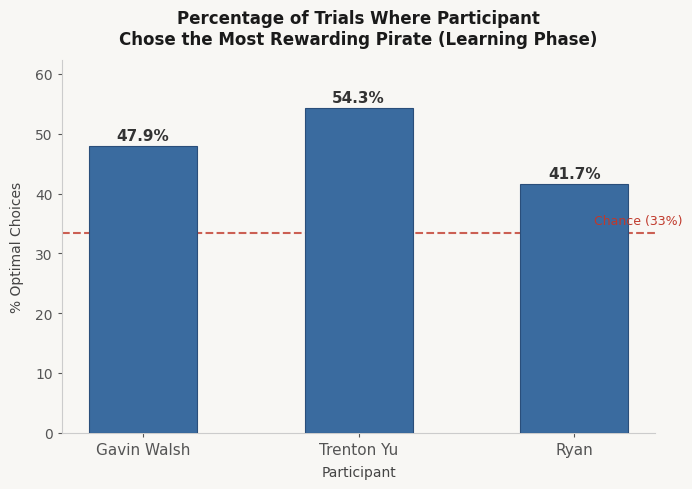

In [92]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#F8F7F4')
ax.set_facecolor('#F8F7F4')

subjects = list(participants.keys())
pct_optimal = []

for subject, df in participants.items():
    learn = df[df['phase'] == 'learn'].copy()
    
    # Ground truth best pirate per island = highest average pR during learning
    avg_probs = learn.groupby('context_im')[['pR_red', 'pR_white', 'pR_black']].mean()
    best_pirate = avg_probs.idxmax(axis=1).str.replace('pR_', '').to_dict()
    
    # Filter to valid trials only
    valid = learn.dropna(subset=['chosen_pirate', 'rt']).query('rt >= @RT_THRESHOLD')
    
    pct = (valid['chosen_pirate'] == valid['context_im'].map(best_pirate)).mean() * 100
    pct_optimal.append(pct)
    print(f"{subject}: {pct:.1f}% optimal choices")

x_pos = np.arange(len(subjects))
bars = ax.bar(x_pos, pct_optimal, width=0.5, color='#3A6B9F', edgecolor='#2A4E7A',
              linewidth=0.8, zorder=3)

# Chance line (1/3)
ax.axhline(100/3, color='#C0392B', linewidth=1.5, linestyle='--', alpha=0.8, zorder=2)
ax.text(len(subjects) - 0.5, 100/3 + 1, 'Chance (33%)', ha='right', va='bottom',
        fontsize=9, color='#C0392B')

for xi, pct in enumerate(pct_optimal):
    ax.text(xi, pct + 0.5, f'{pct:.1f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#333333')

ax.set_xticks(x_pos)
ax.set_xticklabels(subjects, fontsize=11)
ax.set_ylabel('% Optimal Choices', fontsize=10, color='#444444', labelpad=8)
ax.set_xlabel('Participant', fontsize=10, color='#444444', labelpad=6)
ax.set_title('Percentage of Trials Where Participant\nChose the Most Rewarding Pirate (Learning Phase)',
             fontsize=12, fontweight='bold', color='#1A1A1A', pad=12)
ax.set_ylim(0, max(pct_optimal) + 8)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#CCCCCC')
    ax.spines[spine].set_linewidth(0.8)
ax.tick_params(colors='#555555', length=3)

plt.tight_layout()
plt.savefig('data/cleaned/optimal_choices.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [ ]:
import glob

# Load all picks files into a dict keyed by subject_id
picks_by_subject = {}
for f in glob.glob("data/cleaned/final_S_*_picks.csv"):
    picks_df = pd.read_csv(f)
    subject = picks_df['subject_id'].iloc[0]
    picks_by_subject[subject] = picks_df

print("Loaded picks for:", list(picks_by_subject.keys()))

Loaded picks for: ['ryan', 'Trenton Yu', 'Gavin Walsh']


In [98]:
for subject, picks in picks_by_subject.items():
    print(f"\n=== {subject} ===")
    print(picks['trial_type'].value_counts())
    print(picks[['trial_type', 'context_im', 'chosen_pirate']].head(10))


=== ryan ===
trial_type
do_pick_best_pirate          6
do_pick_secondBest_pirate    6
Name: count, dtype: int64
                  trial_type context_im chosen_pirate
0        do_pick_best_pirate       city           red
1  do_pick_secondBest_pirate       city         white
2        do_pick_best_pirate      coast           red
3  do_pick_secondBest_pirate      coast         white
4        do_pick_best_pirate     forest         black
5  do_pick_secondBest_pirate     forest         white
6        do_pick_best_pirate   mountain         white
7  do_pick_secondBest_pirate   mountain         black
8        do_pick_best_pirate    highway         white
9  do_pick_secondBest_pirate    highway         black

=== Trenton Yu ===
trial_type
do_pick_best_pirate          6
do_pick_secondBest_pirate    6
Name: count, dtype: int64
                  trial_type   context_im chosen_pirate
0        do_pick_best_pirate  countryside         white
1  do_pick_secondBest_pirate  countryside           red
2     

KeyError: 'Ryan'

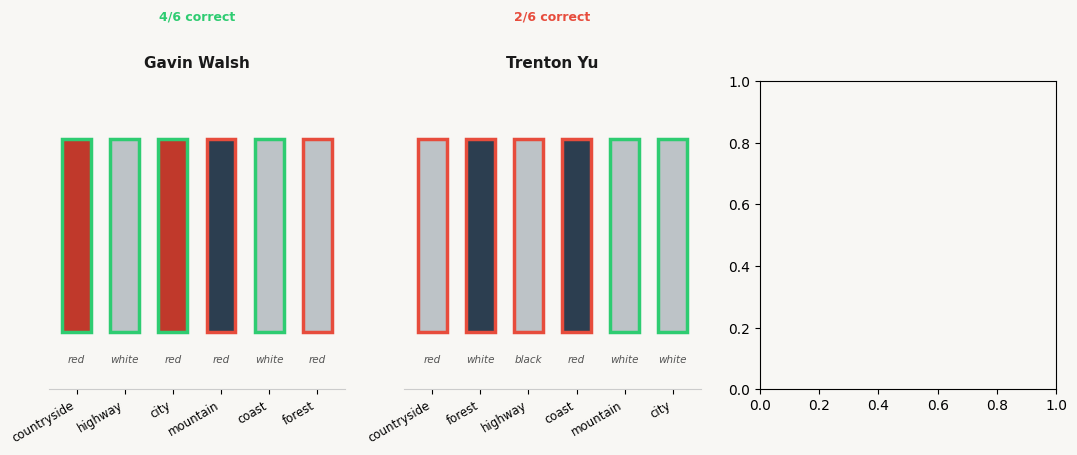

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
fig.patch.set_facecolor('#F8F7F4')

island_order = ['countryside', 'forest', 'highway', 'coast', 'mountain', 'city']

for ax, (subject, df) in zip(axes, participants.items()):
    ax.set_facecolor('#F8F7F4')

    # Load picks for this participant
    picks_path = f"data/cleaned/final_S_{subject.replace(' ', '_')}_picks.csv"
    # handle naming inconsistency
    import glob
    matches = glob.glob(f"data/cleaned/*{subject.split()[0]}*picks.csv")
    picks = picks_by_subject[subject]

    # Ground truth best per island from learning
    learn = df[df['phase'] == 'learn']
    avg_probs = learn.groupby('context_im')[['pR_red', 'pR_white', 'pR_black']].mean()
    best_pirate = avg_probs.idxmax(axis=1).str.replace('pR_', '').to_dict()

    # Best pirate picks only
    best_picks = picks[picks['trial_type'] == 'do_pick_best_pirate'].copy()
    best_picks['ground_truth'] = best_picks['context_im'].map(best_pirate)
    best_picks['correct'] = best_picks['chosen_pirate'] == best_picks['ground_truth']

    islands = best_picks['context_im'].tolist()
    x_pos = np.arange(len(islands))

    pirate_colors = {'red': '#C0392B', 'white': '#BDC3C7', 'black': '#2C3E50'}

    for xi, (_, row) in enumerate(best_picks.iterrows()):
        chosen = row['chosen_pirate']
        gt     = row['ground_truth']
        correct = row['correct']

        # Bar colored by chosen pirate, outlined green/red for correct/incorrect
        edge_color = '#2ECC71' if correct else '#E74C3C'
        ax.bar(xi, 1, color=pirate_colors.get(chosen, '#aaa'),
               edgecolor=edge_color, linewidth=2.5, width=0.6, zorder=3)

        # Show ground truth below
        ax.text(xi, -0.12, gt, ha='center', va='top', fontsize=7.5,
                color='#555555', style='italic')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(islands, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticks([])
    ax.set_title(subject, fontsize=11, fontweight='bold', color='#1A1A1A', pad=10)
    ax.set_ylim(-0.3, 1.3)

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')

    # Legend for this subplot: chosen pirate color + correct/incorrect border
    n_correct = best_picks['correct'].sum()
    ax.text(0.5, 1.2, f'{n_correct}/{len(best_picks)} correct',
            transform=ax.transAxes, ha='center', fontsize=9,
            fontweight='bold', color='#2ECC71' if n_correct > 3 else '#E74C3C')

# Shared legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='#C0392B', label='Chose Red'),
    Patch(facecolor='#BDC3C7', label='Chose White'),
    Patch(facecolor='#2C3E50', label='Chose Black'),
    Patch(facecolor='white', edgecolor='#2ECC71', linewidth=2, label='Correct'),
    Patch(facecolor='white', edgecolor='#E74C3C', linewidth=2, label='Incorrect'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.08))

fig.text(0.5, -0.02, 'Italic text below each bar = ground truth best pirate',
         ha='center', fontsize=8, color='#888888')

fig.suptitle("Did participants correctly identify the best pirate per island?",
             fontsize=13, fontweight='bold', color='#1A1A1A', y=1.02)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('data/cleaned/best_pirate_recall.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()